# Experiment No. 04
## Linear Regression and Residual Analysis

**Aim:** Implement simple linear regression, find the best-fit line between one predictor and the target, analyze residuals, and study the effect of outliers.

**Dataset:** `Housing.csv`

**Predictor:** `area`  
**Target:** `price`

## 1. Import libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

## 2. Load and inspect the dataset

In [2]:
file_name = "Housing.csv"
possible_paths = [Path(file_name), Path("Week 4") / file_name]
csv_path = next((path for path in possible_paths if path.exists()), None)

if csv_path is None:
    raise FileNotFoundError(f"Could not find {file_name}")

data = pd.read_csv(csv_path)

required_columns = {"area", "price"}
if not required_columns.issubset(data.columns):
    raise ValueError("The dataset must contain area and price columns")

data = data.dropna(subset=["area", "price"]).copy()

print("Dataset shape:", data.shape)
print("Missing values in area and price:", data[["area", "price"]].isna().sum().sum())
data.head()

Dataset shape: (545, 13)
Missing values in area and price: 0


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
data[["area", "price"]].describe().round(2)

,area,price
count,545.00,545.00
mean,5150.54,4766729.25
std,2170.14,1870439.62
min,1650.00,1750000.00
25%,3600.00,3430000.00
50%,4600.00,4340000.00
75%,6360.00,5740000.00
max,16200.00,13300000.00


## 3. Select the predictor and plot it against the target

Lab 4 requires one predictor, so `area` is used to predict `price`. The other dataset columns are not used in this simple regression model.

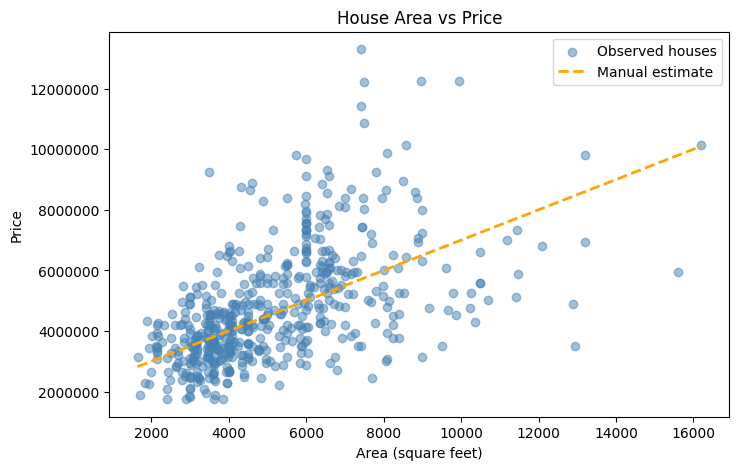

Correlation between area and price: 0.5360


In [4]:
correlation = data["area"].corr(data["price"])
manual_area = np.array([data["area"].min(), data["area"].max()])
manual_price = 2000000 + 500 * manual_area

plt.figure(figsize=(8, 5))
plt.scatter(data["area"], data["price"], alpha=0.5, color="steelblue", label="Observed houses")
plt.plot(manual_area, manual_price, color="orange", linestyle="--", linewidth=2, label="Manual estimate")
plt.xlabel("Area (square feet)")
plt.ylabel("Price")
plt.title("House Area vs Price")
plt.ticklabel_format(style="plain", axis="y")
plt.legend()
plt.show()

print(f"Correlation between area and price: {correlation:.4f}")

**Initial observation:** The scatter plot shows a moderate upward trend: larger houses generally cost more. Therefore, the manually estimated line has a positive slope.

## 4. Split the data and train the model

In [5]:
X = data[["area"]]
y = data["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 436
Testing rows: 109


## 5. Slope, intercept, predictions, and performance

The regression equation is:

$$\text{Predicted Price} = \text{Intercept} + \text{Slope} \times \text{Area}$$

In [6]:
slope = model.coef_[0]
intercept = model.intercept_
test_predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, test_predictions)
rmse = mean_squared_error(y_test, test_predictions) ** 0.5
r2 = r2_score(y_test, test_predictions)

print(f"Regression equation: Price = {intercept:.2f} + ({slope:.4f} x Area)")

model_results = pd.DataFrame({
    "Measure": ["Slope", "Intercept", "MAE", "RMSE", "R-squared"],
    "Value": [slope, intercept, mae, rmse, r2],
})
model_results.round(3)

Regression equation: Price = 2512254.26 + (425.7298 x Area)


,Measure,Value
0,Slope,425.730
1,Intercept,2512254.264
2,MAE,1474748.134
3,RMSE,1917103.702
4,R-squared,0.273


## 6. Plot the fitted regression line

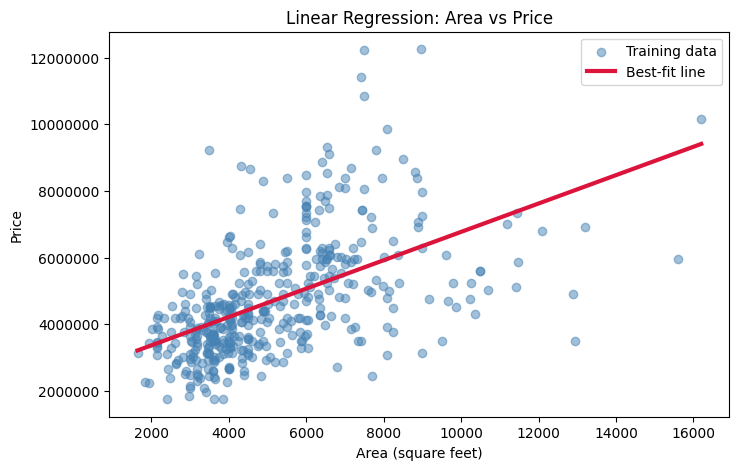

In [7]:
line_area = pd.DataFrame({
    "area": np.linspace(X_train["area"].min(), X_train["area"].max(), 100)
})
line_price = model.predict(line_area)

plt.figure(figsize=(8, 5))
plt.scatter(X_train["area"], y_train, alpha=0.5, color="steelblue", label="Training data")
plt.plot(line_area["area"], line_price, color="crimson", linewidth=3, label="Best-fit line")
plt.xlabel("Area (square feet)")
plt.ylabel("Price")
plt.title("Linear Regression: Area vs Price")
plt.ticklabel_format(style="plain", axis="y")
plt.legend()
plt.show()

## 7. Calculate and analyze residuals

$$\text{Residual} = \text{Actual Price} - \text{Predicted Price}$$

In [8]:
fitted_values = model.predict(X_train)
residuals = y_train - fitted_values

residual_table = pd.DataFrame({
    "Actual Price": y_train,
    "Predicted Price": fitted_values,
    "Residual": residuals,
})
residual_table.head(10).round(2)

,Actual Price,Predicted Price,Residual
46,7525000,5066633.32,2458366.68
93,6300000,5577509.13,722490.87
335,3920000,4136839.34,-216839.34
412,3430000,3623409.15,-193409.15
471,3010000,4108741.17,-1098741.17
237,4620000,4645160.77,-25160.77
544,1750000,4151314.16,-2401314.16
470,3010000,4673258.94,-1663258.94
511,2520000,3866075.16,-1346075.16
361,3710000,5075147.91,-1365147.91


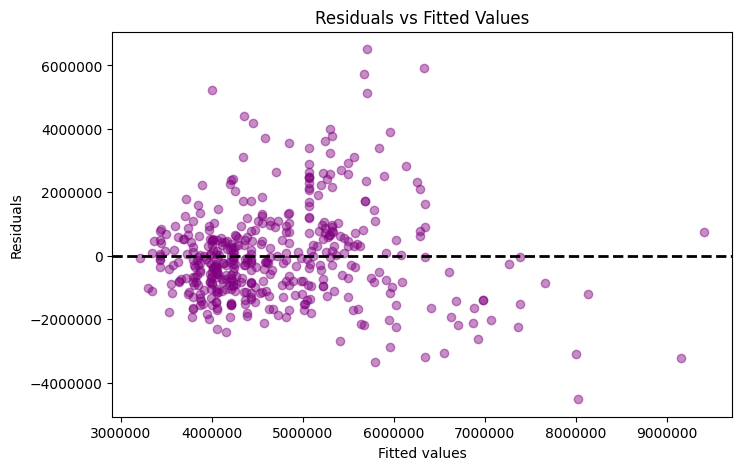

Mean residual: -0.000000


In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(fitted_values, residuals, alpha=0.45, color="purple")
plt.axhline(y=0, color="black", linestyle="--", linewidth=2)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.ticklabel_format(style="plain")
plt.show()

print(f"Mean residual: {residuals.mean():.6f}")

### Residual observations and assumptions

- The residuals are centered around zero.
- No strong curved pattern is visible, so a straight line is a reasonable starting model.
- The residual spread becomes wider for larger fitted values, producing a mild funnel shape. This suggests heteroscedasticity.
- No clear separate clusters are visible.
- The remaining large residuals show that `area` alone cannot explain all differences in `price`.
- Independence cannot be confirmed from this plot alone because the dataset does not provide a time or observation order.

## 8. Add four artificial outliers and refit the model

These artificial observations have very large areas but unusually low prices. They are added only to the training data; the test data remains unchanged.

In [10]:
outliers = pd.DataFrame({
    "area": [18000, 20000, 22000, 24000],
    "price": [2000000, 2200000, 2400000, 2600000],
})

X_train_outliers = pd.concat([X_train, outliers[["area"]]], ignore_index=True)
y_train_outliers = pd.concat([y_train, outliers["price"]], ignore_index=True)

outlier_model = LinearRegression()
outlier_model.fit(X_train_outliers, y_train_outliers)
outlier_test_predictions = outlier_model.predict(X_test)

outliers

,area,price
0,18000,2000000
1,20000,2200000
2,22000,2400000
3,24000,2600000


## 9. Compare the original and outlier-affected models

In [11]:
original_values = [
    model.coef_[0],
    model.intercept_,
    mean_absolute_error(y_test, test_predictions),
    r2_score(y_test, test_predictions),
]

outlier_values = [
    outlier_model.coef_[0],
    outlier_model.intercept_,
    mean_absolute_error(y_test, outlier_test_predictions),
    r2_score(y_test, outlier_test_predictions),
]

comparison = pd.DataFrame({
    "Parameter": ["Slope", "Intercept", "Test MAE", "Test R-squared"],
    "Original Model": original_values,
    "With Outliers": outlier_values,
    "Change": np.array(outlier_values) - np.array(original_values),
})
comparison.round(3)

,Parameter,Original Model,With Outliers,Change
0,Slope,425.730,239.926,-185.804
1,Intercept,2512254.264,3413476.705,901222.441
2,Test MAE,1474748.134,1571254.600,96506.466
3,Test R-squared,0.273,0.175,-0.098


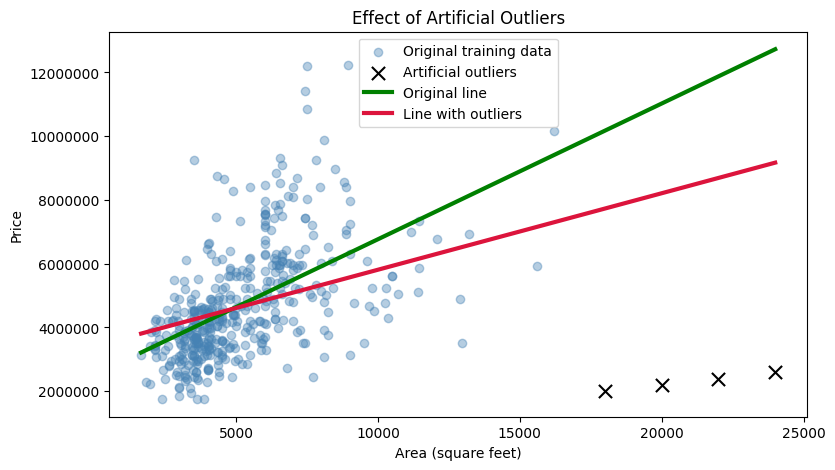

In [12]:
full_area = pd.DataFrame({
    "area": np.linspace(data["area"].min(), outliers["area"].max(), 150)
})

plt.figure(figsize=(9, 5))
plt.scatter(X_train["area"], y_train, alpha=0.4, color="steelblue", label="Original training data")
plt.scatter(outliers["area"], outliers["price"], color="black", marker="x", s=90, label="Artificial outliers")
plt.plot(full_area["area"], model.predict(full_area), color="green", linewidth=3, label="Original line")
plt.plot(full_area["area"], outlier_model.predict(full_area), color="crimson", linewidth=3, label="Line with outliers")
plt.xlabel("Area (square feet)")
plt.ylabel("Price")
plt.title("Effect of Artificial Outliers")
plt.ticklabel_format(style="plain", axis="y")
plt.legend()
plt.show()

## 10. Final observation and conclusion

In [13]:
print(f"area-price correlation: {correlation:.4f}")
print(f"Original test R-squared: {r2:.4f}")
print(f"Original slope: {model.coef_[0]:.4f}")
print(f"Slope with outliers: {outlier_model.coef_[0]:.4f}")
print(f"Slope change: {outlier_model.coef_[0] - model.coef_[0]:.4f}")

print("\nConclusion:")
print("1. Area is a useful but incomplete individual predictor of price in this dataset.")
print("2. The positive correlation and positive test R-squared support this conclusion.")
print("3. The artificial outliers noticeably change the slope and intercept.")
print("4. Ordinary least-squares linear regression is sensitive to extreme observations.")
print("5. A better model should also use bedrooms, bathrooms, stories, parking, air conditioning, preferred area, and furnishing status.")

area-price correlation: 0.5360
Original test R-squared: 0.2729
Original slope: 425.7298
Slope with outliers: 239.9256
Slope change: -185.8043

Conclusion:
1. Area is a useful but incomplete individual predictor of price in this dataset.
2. The positive correlation and positive test R-squared support this conclusion.
3. The artificial outliers noticeably change the slope and intercept.
4. Ordinary least-squares linear regression is sensitive to extreme observations.
5. A better model should also use bedrooms, bathrooms, stories, parking, air conditioning, preferred area, and furnishing status.


## 11. Checks

In [14]:
assert {"area", "price"}.issubset(data.columns)
assert data[["area", "price"]].isna().sum().sum() == 0
assert X_train.index.intersection(X_test.index).empty
assert np.allclose(residuals, y_train - model.predict(X_train))
assert len(outliers) == 4
print("All checks passed.")

All checks passed.


## Viva Questions - Short Answers

1. **What is linear regression?** It models a linear relationship between a predictor and a numeric target.
2. **What is the simple regression equation?** $y = b_0 + b_1x$.
3. **What does the slope represent?** The predicted change in the target for a one-unit increase in the predictor.
4. **What is a residual?** Actual value minus predicted value.
5. **What should an ideal residual plot look like?** Random points around zero with roughly constant spread.
6. **What does a funnel shape indicate?** Heteroscedasticity, or non-constant residual variance.
7. **Why are outliers dangerous?** They can pull the least-squares line and change its parameters.
8. **What is homoscedasticity?** Approximately constant residual variance.
9. **What does R-squared represent?** The proportion of target variation explained by the model.
10. **What is least squares?** A method that minimizes the sum of squared residuals.